# 05 - Model Evaluation

This notebook evaluates the classifiers trained on the DDXPlus-derived feature matrix and shows presentation-ready metrics, confusion matrices, and differential diagnosis examples.

In [1]:
import sys
from pathlib import Path

_nb = Path.cwd().resolve()
for _c in [_nb, _nb.parent, _nb.parent.parent]:
    if (_c / "app" / "main.py").exists():
        sys.path.insert(0, str(_c))
        break

from training.notebooks.bootstrap import require_ddxplus

ctx = require_ddxplus()
repo_root = ctx.repo_root
raw_path = ctx.raw_train_csv
processed_dir = ctx.processed_dir
training_models_dir = ctx.training_models_dir
runtime_models_dir = ctx.runtime_models_dir

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

X_test = pd.read_csv(processed_dir / "X_test.csv")
y_test = pd.read_csv(processed_dir / "y_test.csv")["target"]

# Try runtime_models_dir first, then training_models_dir
model_path = runtime_models_dir / "xgboost_model.pkl"
if not model_path.exists():
    model_path = training_models_dir / "xgboost_model.pkl"
if not model_path.exists():
    raise FileNotFoundError(f"Train/export first: missing {model_path}")

model = joblib.load(model_path)
label_encoder = joblib.load(runtime_models_dir / "label_encoder.joblib")
print("Loaded model:", model_path)

# Generate predictions
preds = model.predict(X_test)
print(f"Predictions shape: {preds.shape}")
print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=label_encoder.classes_, zero_division=0))

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:00:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\data\../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


Loaded model: C:\healix-ai-medical-assistant\models\xgboost_model.pkl
Predictions shape: (5000,)

Classification Report:
                                          precision    recall  f1-score   support

     Acute COPD exacerbation / infection       1.00      1.00      1.00        87
                Acute dystonic reactions       1.00      1.00      1.00       136
                        Acute laryngitis       0.99      1.00      1.00       114
                      Acute otitis media       1.00      1.00      1.00       123
                   Acute pulmonary edema       1.00      1.00      1.00        88
                    Acute rhinosinusitis       1.00      0.74      0.85        66
                      Allergic sinusitis       1.00      1.00      1.00       196
                             Anaphylaxis       1.00      1.00      1.00       126
                                  Anemia       1.00      1.00      1.00       237
                     Atrial fibrillation       1.00      1

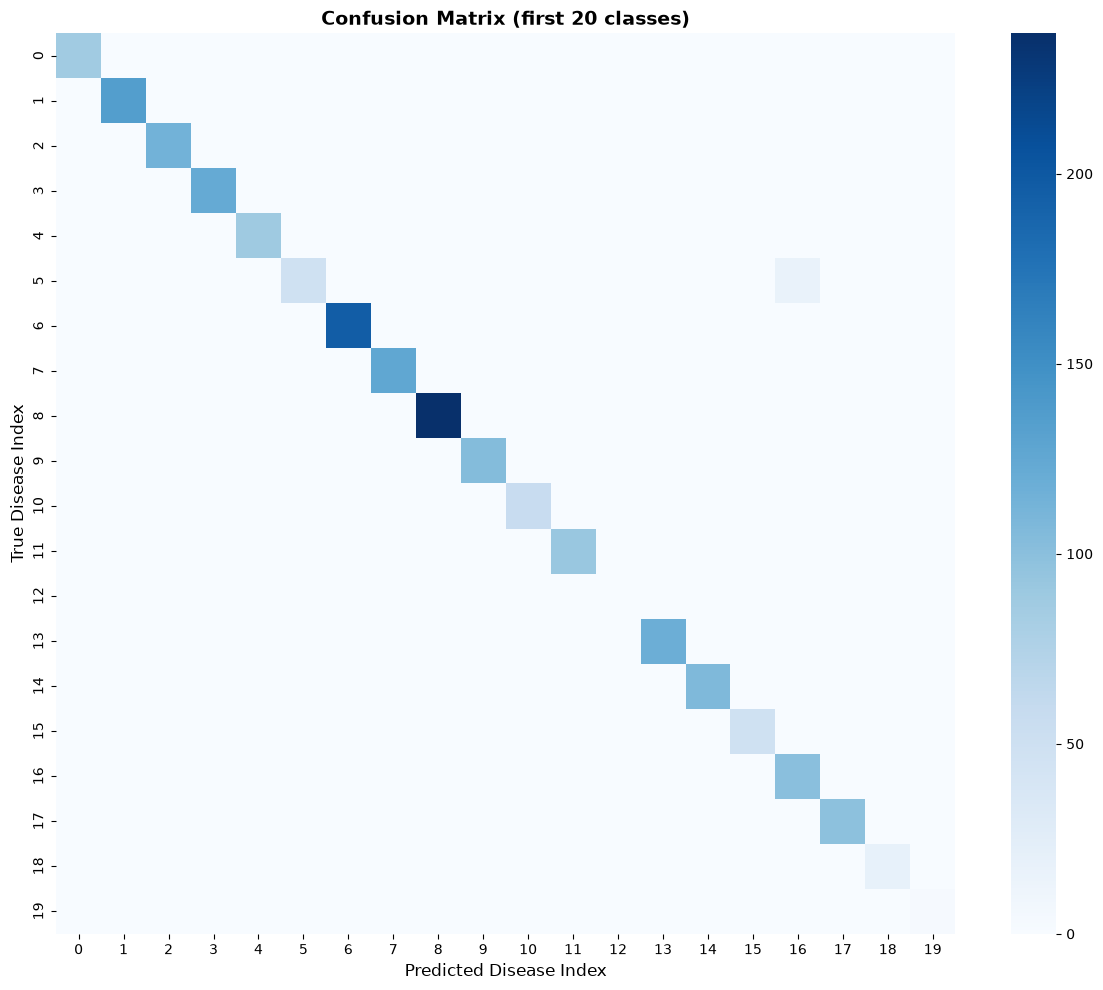

Confusion matrix shape: (49, 49)


In [2]:
# Confusion matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm[:20, :20], annot=False, cmap="Blues", cbar=True)
plt.title("Confusion Matrix (first 20 classes)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Disease Index", fontsize=12)
plt.ylabel("True Disease Index", fontsize=12)
plt.tight_layout()
plt.show()
print(f"Confusion matrix shape: {cm.shape}")

In [3]:
# ROC-AUC for multi-class using one-vs-rest
classes = label_encoder.classes_
print(f"Number of classes: {len(classes)}")
try:
    y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))
    proba = model.predict_proba(X_test)
    macro_auc = roc_auc_score(y_test_bin, proba, average="macro")
    weighted_auc = roc_auc_score(y_test_bin, proba, average="weighted")
    print(f"Macro ROC-AUC: {round(macro_auc, 4)}")
    print(f"Weighted ROC-AUC: {round(weighted_auc, 4)}")
except Exception as exc:
    print("ROC-AUC unavailable for this configuration:")
    print(f"  Error: {type(exc).__name__}: {exc}")

Number of classes: 49
ROC-AUC unavailable for this configuration:
  Error: ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.


In [4]:
# Top predicted diseases for real DDXPlus feature rows
sample_indices = [0, 1, 2]
for index in sample_indices:
    sample_vector = X_test.iloc[index].to_frame().T
    active_evidence = [col for col in sample_vector.columns if col.startswith("E_") and int(sample_vector.iloc[0][col]) == 1]
    proba = model.predict_proba(sample_vector)[0]
    class_indices = np.arange(len(proba))
    disease_names = label_encoder.inverse_transform(class_indices)
    ranking = sorted(zip(disease_names, proba), key=lambda item: item[1], reverse=True)[:5]
    print(f"Example case {index}")
    print(f"Active evidence ({len(active_evidence)} total):", active_evidence[:15])
    print("Top 5 differential diagnoses:")
    for disease, probability in ranking:
        print(f"  - {disease}: {probability:.4f}")
    print("---")

Example case 0
Active evidence (17 total): ['E_111', 'E_138', 'E_148', 'E_177', 'E_185', 'E_204', 'E_53', 'E_54', 'E_55', 'E_56', 'E_57', 'E_58', 'E_59', 'E_66', 'E_75']
Top 5 differential diagnoses:
  - Panic attack: 0.9988
  - Boerhaave: 0.0011
  - Myocarditis: 0.0001
  - Pericarditis: 0.0000
  - Bronchiolitis: 0.0000
---
Example case 1
Active evidence (15 total): ['E_123', 'E_204', 'E_219', 'E_53', 'E_54', 'E_55', 'E_56', 'E_57', 'E_58', 'E_59', 'E_66', 'E_77', 'E_79', 'E_91', 'E_97']
Top 5 differential diagnoses:
  - Bronchitis: 1.0000
  - Myocarditis: 0.0000
  - Spontaneous pneumothorax: 0.0000
  - Ebola: 0.0000
  - Acute laryngitis: 0.0000
---
Example case 2
Active evidence (7 total): ['E_0', 'E_156', 'E_157', 'E_204', 'E_66', 'E_83', 'E_93']
Top 5 differential diagnoses:
  - Guillain-Barré syndrome: 1.0000
  - Ebola: 0.0000
  - Myocarditis: 0.0000
  - Croup: 0.0000
  - Bronchiolitis: 0.0000
---


In [5]:
# Error analysis
errors = pd.DataFrame({"true": y_test, "pred": preds})
errors["true_name"] = label_encoder.inverse_transform(errors["true"])
errors["pred_name"] = label_encoder.inverse_transform(errors["pred"])
errors["is_error"] = errors["true"] != errors["pred"]
error_count = errors["is_error"].sum()
accuracy = (1 - error_count / len(errors)) * 100
print(f"Overall Accuracy: {accuracy:.2f}%")
print(f"Total Errors: {error_count} / {len(errors)}")
print("\nFirst 10 errors:")
error_rows = errors[errors["is_error"]][["true_name", "pred_name"]].head(10)
print(error_rows.to_string())

Overall Accuracy: 99.54%
Total Errors: 23 / 5000

First 10 errors:
                 true_name               pred_name
4             Pericarditis             Myocarditis
142   Acute rhinosinusitis  Chronic rhinosinusitis
656   Acute rhinosinusitis  Chronic rhinosinusitis
686   Acute rhinosinusitis  Chronic rhinosinusitis
696   Acute rhinosinusitis  Chronic rhinosinusitis
791   Acute rhinosinusitis  Chronic rhinosinusitis
1052  Acute rhinosinusitis  Chronic rhinosinusitis
1111  Acute rhinosinusitis  Chronic rhinosinusitis
1522  Acute rhinosinusitis  Chronic rhinosinusitis
1888  Acute rhinosinusitis  Chronic rhinosinusitis


## Interpretation

- The classification report shows overall performance and per-class behavior on the DDXPlus-derived feature matrix.
- The confusion matrix highlights where the model confuses similar conditions.
- The differential diagnosis ranking shows probability-based outputs suitable for a clinical decision support system.
- The output is explicitly framed as a differential diagnosis / possible conditions list, not a final diagnosis.